# Collaborative Filtering Recommendation System

## 1. Problem Statement

### Problem Definition

The objective of this project is to build a Collaborative Filtering 
Recommendation System that recommends movies to users based on the preferences 
of similar users.

The system analyzes user-item interactions (ratings) and identifies patterns 
among users to generate personalized recommendations.

### Dataset Used

Dataset: MovieLens Dataset

The dataset contains:

- User IDs
- Movie IDs
- Movie Ratings
- Timestamp

The recommendation system uses user rating behavior to recommend movies.

In [1]:
# Install Surprise library if required

!pip install scikit-surprise

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from surprise import Dataset
from surprise import Reader

from surprise import KNNBasic

from surprise.model_selection import train_test_split

from surprise import accuracy

In [3]:
# Load MovieLens dataset

data = Dataset.load_builtin(
    'ml-100k'
)

In [4]:
ratings = pd.DataFrame(
    data.raw_ratings,
    columns=[
        "userId",
        "movieId",
        "rating",
        "timestamp"
    ]
)


ratings.head()

,userId,movieId,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596


In [5]:
ratings.shape

(100000, 4)

In [6]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [7]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100000 non-null  str    
 1   movieId    100000 non-null  str    
 2   rating     100000 non-null  float64
 3   timestamp  100000 non-null  str    
dtypes: float64(1), str(3)
memory usage: 3.1 MB


In [8]:
ratings.describe()

,rating
count,100000.000000
mean,3.529860
std,1.125674
min,1.000000
25%,3.000000
50%,4.000000
75%,4.000000
max,5.000000


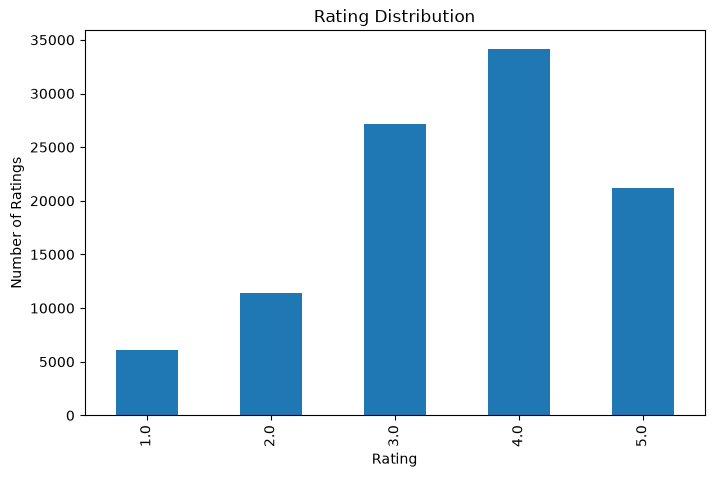

In [9]:
plt.figure(figsize=(8,5))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar'
)

plt.xlabel("Rating")

plt.ylabel("Number of Ratings")

plt.title("Rating Distribution")

plt.show()

In [10]:
ratings_data = ratings[
    [
        "userId",
        "movieId",
        "rating"
    ]
]

In [11]:
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [12]:
similarity_options = {

    "name":"cosine",

    "user_based":True
}


model = KNNBasic(
    sim_options=similarity_options
)

In [13]:
model.fit(
    trainset
)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [14]:
predictions = model.test(
    testset
)

In [15]:
accuracy.rmse(
    predictions
)

RMSE: 1.0194


np.float64(1.0193536815834319)

In [16]:
user_id = 1


similar_users = model.get_neighbors(
    user_id,
    k=5
)


similar_users

[6, 65, 81, 131, 133]

In [17]:
def recommend_movies(user_id, n=5):

    all_movies = ratings[
        'movieId'
    ].unique()


    watched_movies = ratings[
        ratings['userId']==user_id
    ]['movieId'].values


    recommendations=[]


    for movie in all_movies:

        if movie not in watched_movies:

            prediction = model.predict(
                user_id,
                movie
            )


            recommendations.append(
                (
                    movie,
                    prediction.est
                )
            )


    recommendations = sorted(
        recommendations,
        key=lambda x:x[1],
        reverse=True
    )


    return recommendations[:n]

In [18]:
recommend_movies(
    1,
    5
)

[('242', np.float64(3.5318875)),
 ('302', np.float64(3.5318875)),
 ('377', np.float64(3.5318875)),
 ('51', np.float64(3.5318875)),
 ('346', np.float64(3.5318875))]

In [19]:
def precision_at_k(recommended, relevant, k):

    recommended = recommended[:k]

    hits = len(
        set(recommended)
        &
        set(relevant)
    )

    return hits/k

In [20]:
def recall_at_k(recommended, relevant, k):

    recommended = recommended[:k]

    hits = len(
        set(recommended)
        &
        set(relevant)
    )

    return hits/len(relevant)

# Result Interpretation

The Collaborative Filtering Recommendation System recommends movies by 
analyzing user behavior and finding similarities between users.

The system identifies users with similar preferences and recommends movies 
liked by those similar users.

The model performance is evaluated using prediction accuracy and 
recommendation metrics.

Evaluation metrics used:

- Precision@K
- Recall@K
- Recommendation Examples


# Conclusion

In this project, a Collaborative Filtering Recommendation System was 
implemented using the MovieLens dataset.

The system successfully learned user preferences from historical ratings 
and generated personalized movie recommendations.

Collaborative filtering is useful when user interaction data is available 
and personalized recommendations are required.